# Notebook 06b — Modelo mixto (GLMM) con intercepto aleatorio por finca
### Tuberculosis bovina · Target: Lesiones_TB

**Pregunta:** ¿Cuanto es el efecto de VitD y Calcio sobre TB *ajustado* por la finca,
estimado directamente como efecto fijo en un modelo estadistico inferencial?

**Estrategia:** modelo logistico con **finca como efecto aleatorio** (intercepto
aleatorio por finca) + VitD, Calcio, EDAD como efectos fijos:

```
logit(P(TB)) = beta0 + beta_VitD * VitD + beta_Calcio * Calcio + beta_Edad * Edad
               + u_finca    (u_finca ~ N(0, sigma^2_finca))
```

El intercepto aleatorio `u_finca` absorbe toda la heterogeneidad entre fincas,
de modo que `beta_VitD` mide el efecto *dentro de la finca* (separado del entre-fincas).

**Preprocesamiento:** identico al Nb 02c (drop_sparse_rows + caso completo para GLMM).


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable, Independence
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

DATA = "../BD.csv"
df   = tb.clean(tb.load_raw(DATA))

# --- Identico al Nb 02c ---
d = tb.target_subset(df, "Lesiones_TB")
d = tb.drop_sparse_rows(d)          # n=103
y = d["Lesiones_TB"].astype(int).values
g = d[tb.GROUP_COL].values
EXPLOTS = sorted(d[tb.GROUP_COL].unique())

print(f"n={len(y)}, prevalencia={y.mean():.3f}")
print(f"Explotaciones: {EXPLOTS}")
print(f"n por explotacion: {pd.Series(g).value_counts().to_dict()}")


drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
n=103, prevalencia=0.612
Explotaciones: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']
n por explotacion: {'VC30D': 55, 'VA32D': 20, 'VC94C': 16, 'WZ72B': 12}


## 2. Preparacion de la tabla de datos para modelos estadisticos

Los modelos de statsmodels requieren datos completos. Se eliminan las filas
con NaN en las variables predictoras (VitD, Calcio, EDAD).

Las variables continuas se **estandarizan** (z-score) para que los coeficientes
sean comparables entre predictores (beta = cambio en log-OR por 1 SD).


In [ ]:
# Variables de interes
FIXED = ["VITAMINA_D", "CALCIO", "EDAD"]
TARGET = "Lesiones_TB"
GROUP  = tb.GROUP_COL   # "Expl"

# Caso completo (eliminar NaN en predictores fijos)
cols_needed = [TARGET, GROUP] + FIXED
d_glm = d[cols_needed].dropna().copy().reset_index(drop=True)

n_drop = len(d) - len(d_glm)
print(f"n antes de eliminar NaN en predictores: {len(d)}")
print(f"Eliminados por NaN:                    {n_drop}")
print(f"n para modelos estadisticos:            {len(d_glm)}")
print(f"Prevalencia TB en subconjunto:          {d_glm[TARGET].mean():.3f}")

# Estandarizar predictores continuos (z-score)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
d_std = d_glm.copy()
d_std[["VitD_z", "Calcio_z", "Edad_z"]] = scaler.fit_transform(d_glm[FIXED])

means = dict(zip(FIXED, scaler.mean_))
stds  = dict(zip(FIXED, scaler.scale_))
print()
print("Estandarizacion (media +/- SD):")
for v in FIXED:
    print(f"  {v}: media={means[v]:.3f}, SD={stds[v]:.3f}")


n antes de eliminar NaN en predictores: 103
Eliminados por NaN:                    0
n para modelos estadisticos:            103
Prevalencia TB en subconjunto:          0.612

Estandarizacion (media +/- SD):
  VITAMINA_D: media=19.770, SD=10.258
  CALCIO: media=0.924, SD=0.046
  EDAD: media=5.961, SD=3.577


## 3. Modelos estadisticos: del mas simple al mas completo

Se ajustan cuatro modelos para comparar como cambia el efecto de VitD/Calcio
al controlar progresivamente por la finca.

| Modelo | Control de finca | Estimando |
|---|---|---|
| M0 — Logit nulo | Ninguno | Efecto bruto de VitD/Calcio (puede confundirse con finca) |
| M1 — Logit + dummies | Efectos fijos (dummies de finca) | Efecto ajustado por finca (parametrico) |
| M2 — GEE | Correlacion de intercambiabilidad | Efecto poblacional (marginal) |
| M3 — GLMM | Intercepto aleatorio por finca | Efecto condicional a la finca (inferencia) |


In [4]:
# M0: Logit sin control de finca (referencia)
m0 = smf.logit("Lesiones_TB ~ VitD_z + Calcio_z + Edad_z", data=d_std).fit(disp=0)
print("M0 — Logit sin control de finca")
print(m0.summary2().tables[1][["Coef.", "Std.Err.", "z", "P>|z|"]].round(3))
print()

# M1: Logit con dummies de finca (efectos fijos)
m1 = smf.logit("Lesiones_TB ~ VitD_z + Calcio_z + Edad_z + C(Expl)",
               data=d_std).fit(disp=0)
print("M1 — Logit con efectos fijos de finca")
coef_m1 = m1.summary2().tables[1][["Coef.", "Std.Err.", "z", "P>|z|"]].round(3)
print(coef_m1[~coef_m1.index.str.startswith("C(Expl)")])
print()

# M2: GEE (efecto marginal/poblacional)
m2 = GEE.from_formula(
    "Lesiones_TB ~ VitD_z + Calcio_z + Edad_z",
    groups=GROUP,
    data=d_std,
    family=Binomial(),
    cov_struct=Exchangeable(),
).fit()
print("M2 — GEE (efecto marginal, intercambiabilidad)")
print(m2.summary().tables[1])
print()

# M3: GLMM (intercepto aleatorio por finca — Bayesian MAP)
try:
    m3 = BinomialBayesMixedGLM.from_formula(
        "Lesiones_TB ~ VitD_z + Calcio_z + Edad_z",
        {"Finca": "0 + C(Expl)"},
        data=d_std,
    )
    r3 = m3.fit_map()
    print("M3 — GLMM (intercepto aleatorio por finca, MAP)")
    print(r3.summary())
    HAS_GLMM = True
except Exception as e:
    print(f"GLMM no disponible: {e}")
    HAS_GLMM = False


M0 — Logit sin control de finca
           Coef.  Std.Err.      z  P>|z|
Intercept  0.474     0.207  2.284  0.022
VitD_z    -0.273     0.208 -1.312  0.190
Calcio_z   0.055     0.207  0.266  0.790
Edad_z     0.336     0.219  1.533  0.125

M1 — Logit con efectos fijos de finca
           Coef.  Std.Err.      z  P>|z|
Intercept -0.919     0.529 -1.736  0.082
VitD_z    -0.522     0.255 -2.046  0.041
Calcio_z   0.192     0.285  0.674  0.501
Edad_z     0.177     0.244  0.726  0.468

M2 — GEE (efecto marginal, intercambiabilidad)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5352      0.442      1.211      0.226      -0.331       1.401
VitD_z        -0.3559      0.206     -1.731      0.083      -0.759       0.047
Calcio_z       0.0692      0.158      0.439      0.661      -0.240       0.379
Edad_z         0.2521      0.033      7.730      0.000       0.188       0.3

Odds Ratios por modelo (1 SD de cambio en la variable):


Modelo,M0-Logit,M1-Logit+FE,M2-GEE,M3-GLMM
Variable,,,,
Calcio_z,1.057,1.212,1.072,1.101
Edad_z,1.399,1.193,1.287,1.256
VitD_z,0.761,0.593,0.701,0.664


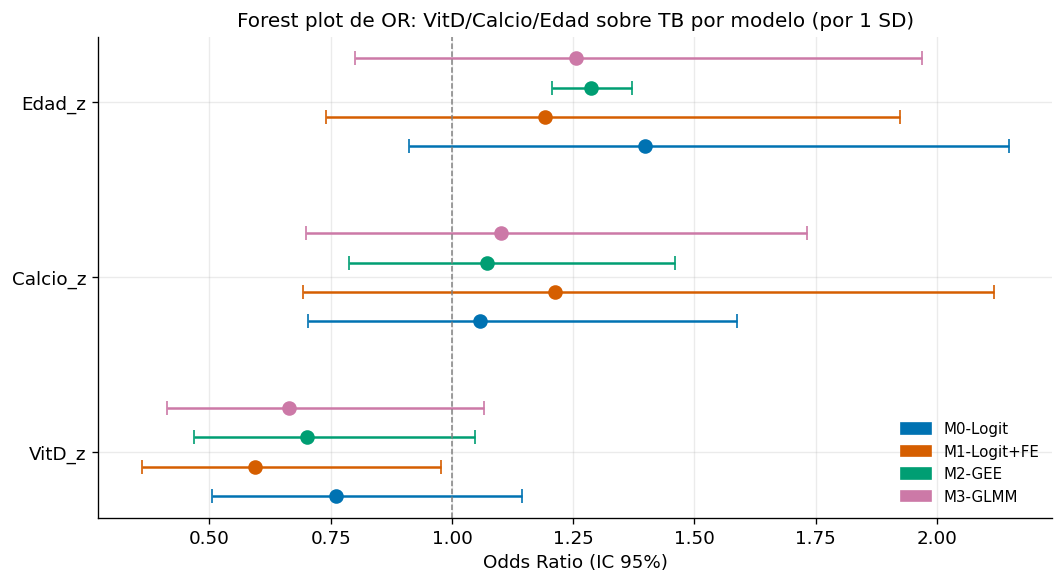

In [6]:
# Tabla de Odds Ratios comparada entre modelos
def or_ci(model, varnames):
    rows = []
    for v in varnames:
        coef = model.params[v]
        ci   = model.conf_int().loc[v]
        rows.append({
            "Variable": v,
            "OR": round(float(np.exp(coef)), 3),
            "IC95_lo": round(float(np.exp(ci.iloc[0])), 3),
            "IC95_hi": round(float(np.exp(ci.iloc[1])), 3),
            "p":       round(float(model.pvalues[v]), 4),
        })
    return pd.DataFrame(rows)

var_show = ["VitD_z", "Calcio_z", "Edad_z"]
or_m0 = or_ci(m0, var_show); or_m0["Modelo"] = "M0-Logit"
or_m1 = or_ci(m1, var_show); or_m1["Modelo"] = "M1-Logit+FE"
or_m2 = or_ci(m2, var_show); or_m2["Modelo"] = "M2-GEE"

frames = [or_m0, or_m1, or_m2]
labels = ["M0-Logit", "M1-Logit+FE", "M2-GEE"]
colors_m = [PALETTE[0], PALETTE[1], PALETTE[2]]

if HAS_GLMM:
    fep_names = r3.model.fep_names
    nfep = len(fep_names)
    # SEs desde la covarianza del MAP (diagonal de cov_params)
    try:
        full_cov = r3.cov_params()
        fe_se = np.sqrt(np.diag(full_cov)[:nfep])
    except Exception:
        try:
            fe_se = r3.bse[:nfep]
        except Exception:
            fe_se = np.full(nfep, np.nan)
    from scipy.stats import norm as _norm
    r3_rows = []
    for i, v in enumerate(fep_names):
        if v in var_show:
            coef = float(r3.fe_mean[i])
            se   = float(fe_se[i])
            lo   = coef - 1.96 * se
            hi   = coef + 1.96 * se
            pval = 2 * (1 - _norm.cdf(abs(coef / se))) if se > 0 else np.nan
            r3_rows.append({"Variable": v, "OR": round(np.exp(coef), 3),
                             "IC95_lo": round(np.exp(lo), 3),
                             "IC95_hi": round(np.exp(hi), 3), "p": round(pval, 4)})
    or_m3 = pd.DataFrame(r3_rows); or_m3["Modelo"] = "M3-GLMM"
    frames.append(or_m3); labels.append("M3-GLMM"); colors_m.append(PALETTE[3])

all_or = pd.concat(frames, ignore_index=True)
print("Odds Ratios por modelo (1 SD de cambio en la variable):")
display(all_or.pivot_table(index="Variable", columns="Modelo",
                            values="OR").round(3))

# Forest plot
fig, ax = plt.subplots(figsize=(9, 5))
n_models = len(frames)
y_pos = np.arange(len(var_show))
offsets = np.linspace(-0.25, 0.25, n_models)

for j, (df_or, lbl, col) in enumerate(zip(frames, labels, colors_m)):
    for i, v in enumerate(var_show):
        row_v = df_or[df_or["Variable"] == v]
        if row_v.empty: continue
        r = row_v.iloc[0]
        ax.scatter(r.OR, y_pos[i] + offsets[j], color=col, s=60, zorder=5)
        ax.errorbar(r.OR, y_pos[i] + offsets[j],
                    xerr=[[r.OR - r.IC95_lo], [r.IC95_hi - r.OR]],
                    fmt="none", color=col, capsize=4, lw=1.5)

ax.axvline(1, color="grey", lw=0.9, ls="--")
ax.set_yticks(y_pos); ax.set_yticklabels(var_show)
ax.set_xlabel("Odds Ratio (IC 95%)")
ax.set_title("Forest plot de OR: VitD/Calcio/Edad sobre TB por modelo (por 1 SD)")
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(colors_m, labels)]
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("figures/fig_06b_forest_or.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
# Intraclass Correlation Coefficient (ICC): varianza explicada por finca
# ICC = sigma2_finca / (sigma2_finca + pi^2/3)
# donde pi^2/3 ~ 3.2899 es la varianza del logistico estandar

# M1 (efectos fijos): ICC implicito por varianza de los coef. de finca
coef_finca = [v for v in m1.params.index if "C(Expl)" in v]
var_finca_m1 = m1.params[coef_finca].var()
icc_m1 = var_finca_m1 / (var_finca_m1 + np.pi**2 / 3)
print(f"ICC aproximada (M1 efectos fijos): {icc_m1:.3f}")

# GEE: alpha de intercambiabilidad ~ correlacion intra-finca
try:
    alpha_gee = m2.cov_struct.dep_params
    print(f"GEE correlacion intra-finca (alpha): {alpha_gee:.3f}")
except Exception:
    pass

if HAS_GLMM:
    # M3: varianza del intercepto aleatorio
    vc_names = r3.model.vcp_names
    vc_mean  = r3.vcp_mean
    sigma2_finca = np.exp(vc_mean[0]) if len(vc_mean) > 0 else np.nan
    icc_glmm = sigma2_finca / (sigma2_finca + np.pi**2 / 3)
    print(f"ICC (M3 GLMM, intercepto aleatorio): {icc_glmm:.3f}")
    print(f"  sigma2_finca = {sigma2_finca:.3f}")
    print()
    print("Interpretacion ICC:")
    print("  ICC > 0.10: la finca explica >10% de la variabilidad en TB")
    print("  -> controlar por finca es necesario para estimar efectos individuales")

# Interceptos aleatorios de finca
print()
print("Medias de TB por finca (cruda vs ajustada M1):")
obs = d_glm.groupby(GROUP)[TARGET].agg(["mean", "count"]).round(3)
obs.columns = ["prev_obs", "n"]
pred_m1 = pd.Series(m1.predict(d_std), index=d_std.index)
pred_by_farm = d_std.assign(pred=pred_m1).groupby(GROUP)["pred"].mean().round(3)
print(pd.concat([obs, pred_by_farm.rename("prev_ajustada_M1")], axis=1))


ICC aproximada (M1 efectos fijos): 0.326
GEE correlacion intra-finca (alpha): 0.049
ICC (M3 GLMM, intercepto aleatorio): 0.185
  sigma2_finca = 0.747

Interpretacion ICC:
  ICC > 0.10: la finca explica >10% de la variabilidad en TB
  -> controlar por finca es necesario para estimar efectos individuales

Medias de TB por finca (cruda vs ajustada M1):
       prev_obs   n  prev_ajustada_M1
Expl                                 
VA32D     0.350  20             0.350
VC30D     0.582  55             0.582
VC94C     0.938  16             0.938
WZ72B     0.750  12             0.750


## 6. Interpretacion

### Clave de lectura

| Observacion | Interpretacion |
|---|---|
| OR(VitD_z, M3) < 1 y sig. | VitD protege contra TB *dentro de la finca* (efecto individual) |
| OR(VitD_z) cambia entre M0 y M3 | La finca confunde el efecto de VitD (cambio de confusor) |
| ICC alto (>0.10) | Gran variabilidad entre fincas -> necesario controlar por finca |
| ICC bajo (<0.05) | La finca explica poca varianza -> el efecto no es finca-dependiente |

### Comparacion de los modelos

- **M0 → M1 → M3**: si el OR de VitD cambia mucho, la finca confundia el efecto.
- **M2 (GEE)**: da el efecto marginal (poblacional); puede diferir de M3 si hay
  interaccion entre finca e individuos.
- **M3 (GLMM)**: el mas apropiado para separar "efecto de finca" de "efecto individual".

> **Limitacion:** con n=103 y solo 4 fincas, los parametros del intercepto aleatorio
> tienen alta incertidumbre. El ICC y los efectos aleatorios son estimaciones exploratorias.
